# Backup all important data files before continue

In [2]:
# from pathlib import Path
# import shutil

# src = Path("data/signal_stat")
# dst = src / "backup"
# dst.mkdir(exist_ok=True)

# for f in src.iterdir():
#     if f.is_file():
#         shutil.copy2(f, dst / f.name)

# Import libraries and set configs

In [3]:
import sys
import os
import random
import warnings
import numpy as np
import pandas as pd
import requests
from os import environ
from datetime import datetime, timedelta
from tqdm.auto import tqdm

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.style as style
from dotenv import load_dotenv, find_dotenv

sys.path.append("..")
sys.path.append("../..")

# use matplotlib style
style.use("fivethirtyeight")

# here we load environment variables from .env, must be called before init. class
load_dotenv(find_dotenv('../.env'), verbose=True)

# Set environment variable
environ["ENV"] = "optimize"

tv_username = os.getenv("TV_USERNAME")
tv_password = os.getenv("TV_PASSWORD")

class CFG:
    # load new data from exchanges
    load = False
    # create dataset from zero
    create_dataset = False
    # update existing dataset
    update_dataset = False
    # TP and SL target ratio
    target_high_ratio = 1.05
    target_low_ratio = 0.95
    # last previous data point to collect for model training (value represents number of hours before signal point)
    last = 272
    # for how long time (in hours) we want to predict
    target_offset = 128
    # what trade types to use: buy, sell, both
    ttype = "both"
    patterns_to_filter = ["STOCH_RSI_Volume24"]
    # period to aggregate
    agg_periods = [24, 72]
    agg_funcs = [np.min, np.max, np.mean, np.median, np.std]
    test_time_days = 90

pd.set_option("display.max_columns", 500)
pd.set_option("display.max_rows", 500)

tqdm.pandas()

warnings.simplefilter(action="ignore", category=(FutureWarning, pd.errors.PerformanceWarning))

# Load data

In [4]:
from ml.utils.ticker_loader import TickerLoader
from config.config import ConfigFactory

pattern = ["STOCH", "RSI", "Volume24"]
test_mode = False

configs = ConfigFactory.factory(environ).configs
configs["Higher_TF_indicator_list"] = ["Trend", "MACD"]
configs["Timeframes"]["work_timeframe"] = "1h"
configs["Timeframes"]["higher_timeframe"] = "4h"

if CFG.load:
    loader = TickerLoader(pattern, test_mode, **configs)
    min_time = datetime.now().replace(microsecond=0, second=0, minute=0) - pd.to_timedelta(365 * 10, unit="D")
    loader.load(min_time)
    for ttype in ["buy", "sell"]:
        print(f"Collect {ttype} stat")
        loader.collect_statistics(ttype, opt_limit=100000)

# Test loaded data

### Remove ticker files and clean them from stat and train dataframes

- if they have a lot of missing or gappy data
- if only 1h or 4h ticker dataframe presents

In [5]:
import glob
from pathlib import Path

tickers_1h = glob.glob("data/tickers/*_1h.pkl")
max_gap_ratio = 0.01
tickers_to_remove = []

def ticker_name(path):                 # data/tickers/CKUSDTUSDT_1h.pkl -> CKUSDTUSDT
    return Path(path).stem[:-3]        # drop "_1h" / "_4h"

# drop ticker files with a lot of missing or gappy data
for ticker in tqdm(tickers_1h):
    df = pd.read_pickle(ticker)
    intervals = df["time"].diff()[1:] # drop leading NaT
    nunique = len(intervals.unique())
    if nunique > 1:
        gap_count = (intervals.astype("timedelta64[s]") != timedelta(hours=1)).sum()
        gap_ratio = gap_count / len(intervals)
        max_gap = intervals.max()
        if gap_ratio > max_gap_ratio or max_gap >= timedelta(hours=48):
            reasons = []
            if gap_ratio > max_gap_ratio:
                reasons.append(f"{gap_ratio * 100:.2f}% non-1h intervals (>{int(max_gap_ratio * 100)}%)")
            if max_gap >= timedelta(hours=48):
                reasons.append(f"max gap {max_gap} (>=48h)")
            print(f"REMOVE {ticker_name(ticker)}: gappy data -> {', '.join(reasons)}")
            os.remove(ticker)
            four_h = ticker[:-6] + "4h.pkl"
            if os.path.exists(four_h):
                os.remove(four_h)
            tickers_to_remove.append(ticker_name(ticker))


# drop *USDTUSDT* files and any unpaired 1h/4h orphans
all_files = glob.glob("data/tickers/*.pkl")
have_1h = {ticker_name(p) for p in all_files if p.endswith("_1h.pkl")}
have_4h = {ticker_name(p) for p in all_files if p.endswith("_4h.pkl")}

for p in all_files:
    name = ticker_name(p)
    if "USDTUSDT" in name:
        reason = "malformed name (contains USDTUSDT)"
    elif name not in have_1h:
        reason = "missing 1h file (orphan 4h)"
    elif name not in have_4h:
        reason = "missing 4h file (orphan 1h)"
    else:
        continue
    if os.path.exists(p):
        print(f"REMOVE {name}: {reason} -> {p}")
        os.remove(p)
        tickers_to_remove.append(name)

tickers_to_remove = list(set(tickers_to_remove))
print(f"\nTotal tickers flagged for removal: {len(tickers_to_remove)}")

# remove flagged tickers from the signal-stat and train datasets
for ttype in ["buy", "sell"]:
    if not tickers_to_remove:
        break

    stat_df = pd.read_pickle(f"data/signal_stat/{ttype}_stat_1h.pkl")
    train_df = pd.read_pickle(f"data/signal_stat/train_{ttype}_272.pkl")
    stat_before, train_before = len(stat_df), len(train_df)

    stat_df = stat_df[~stat_df["ticker"].isin(tickers_to_remove)].reset_index(drop=True)
    train_df = train_df[~train_df["ticker"].isin(tickers_to_remove)].reset_index(drop=True)

    print(
        f"{ttype}: stat_df {stat_before} -> {len(stat_df)} "
        f"(-{stat_before - len(stat_df)} rows), "
        f"train_df {train_before} -> {len(train_df)} "
        f"(-{train_before - len(train_df)} rows)"
    )

    stat_df.to_pickle(f"data/signal_stat/{ttype}_stat_1h.pkl")
    train_df.to_pickle(f"data/signal_stat/train_{ttype}_272.pkl")


  0%|          | 0/4137 [00:00<?, ?it/s]

100%|██████████| 4137/4137 [00:02<00:00, 2060.91it/s]



Total tickers flagged for removal: 0


### Plot time vs index for some of dataframe files

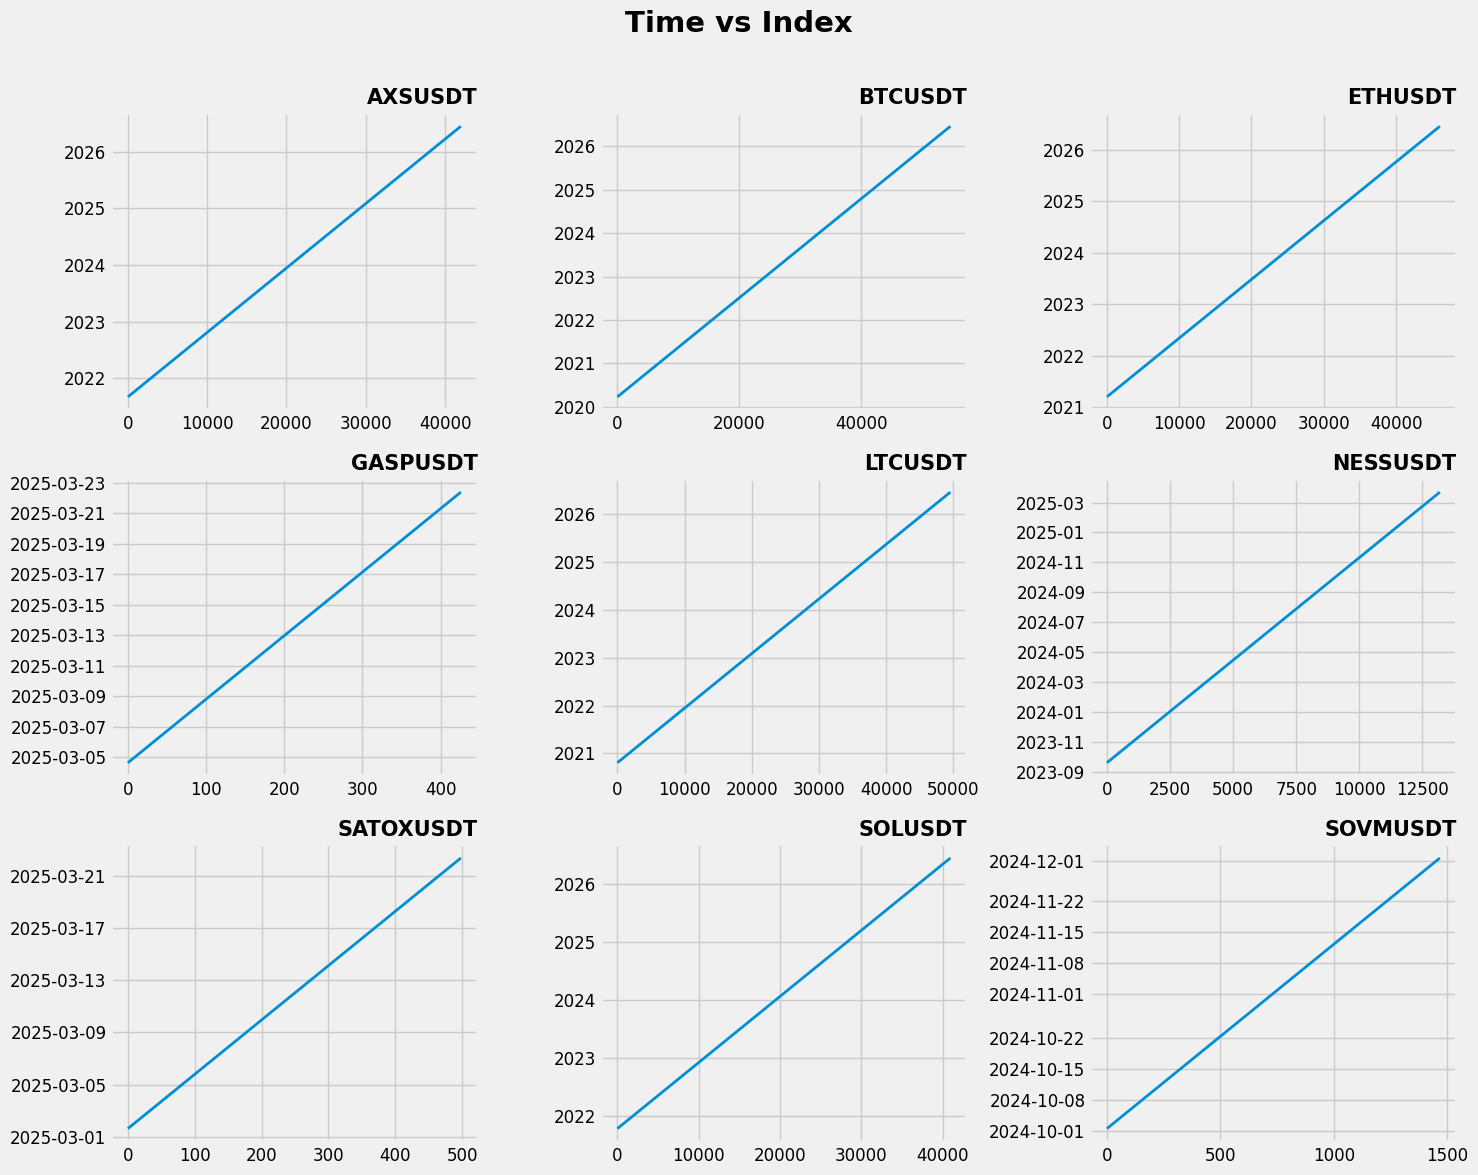

In [6]:
%matplotlib inline

n_cols = 3
n_rows = 3
figsize = (15, 4 * n_rows)

tickers = glob.glob("data/tickers/*_1h.pkl")
random_tickers = random.choices(tickers, k=n_cols*n_rows)
random_tickers[:3] = [t for t in tickers if "/BTCUSDT_1h" in t or "/ETHUSDT_1h" in t or "/LTCUSDT_1h" in t]

def plot_times(random_tickers, n_rows, n_cols):
    fig = plt.figure(figsize=figsize)
    
    for idx in range(n_cols*n_rows):
        ax = plt.subplot(n_rows, n_cols, idx + 1)
        
        df = pd.read_pickle(random_tickers[idx])
        sns.lineplot(data=df["time"])

        ax.set_ylabel("")
        plt.yticks(fontsize=12) 
        ax.set_xlabel("")
        plt.xticks(fontsize=12)
        # ax.spines["right"].set_visible(False)
        ax.set_title(f"{random_tickers[idx].split('/')[-1][:-7]}", loc="right", weight="bold", fontsize=15)
        ax.lines[0].set_linewidth(2)

    
    fig.suptitle("Time vs Index\n", ha="center",  fontweight="bold", fontsize=21)
    # fig.legend([1, 0], loc="upper center", bbox_to_anchor=(0.5, 0.96), fontsize=21, ncol=3)
    plt.tight_layout()
    plt.show()
    
plot_times(sorted(random_tickers),  n_rows=n_rows, n_cols=n_cols) 

### Remove tickers that are in signal stat datasets but corresponding files are missing

# Prepare train data

### Create auxilary datasets

In [7]:
from api.tvdatafeed.main import TvDatafeed, Interval
from utils.data_utils import (
    btcd_cols,
    btcdom_cols,
    create_train_df,
    fng_cols,
    get_file,
)


if CFG.create_dataset:
    # Get BTC dominance
    tv = TvDatafeed(username=tv_username, password=tv_password)

    btcd_new = tv.get_hist("BTC.D","CRYPTOCAP", interval=Interval.in_daily, n_bars=7000, extended_session=True).reset_index()
    btcd_new = btcd_new.drop(columns="symbol")
    btcd_new.columns = btcd_cols
    
    mask = btcd_new["time"].dt.hour == 4
    btcd_new.loc[mask, "time"] = btcd_new.loc[mask, "time"] - pd.to_timedelta(1, unit="h")

    btcd_path = "data/context/btcd.csv"
    if os.path.exists(btcd_path):
        btcd_prev = pd.read_csv(btcd_path, parse_dates=["time"])
        btcd = pd.concat([btcd_prev, btcd_new]).drop_duplicates("time").sort_values("time").reset_index(drop=True)
    else:
        btcd = btcd_new
    btcd.iloc[:-1].to_csv(btcd_path, index=False)
    btcd_new["time"] = btcd_new["time"] + pd.to_timedelta(23, unit="h")

    btcdom_new = tv.get_hist("BTCDOMUSDT.P","BINANCE", interval=Interval.in_4_hour, n_bars=7000, extended_session=True).reset_index()
    btcdom_new = btcdom_new.drop(columns="symbol")
    btcdom_new.columns = btcdom_cols
    
    btcdom_path = "data/context/btcdom.csv"
    if os.path.exists(btcdom_path):
        btcdom_prev = pd.read_csv(btcdom_path, parse_dates=["time"])
        btcdom = pd.concat([btcdom_prev, btcdom_new]).drop_duplicates("time").sort_values("time").reset_index(drop=True)
    else:
        btcdom = btcdom_new
    btcdom.iloc[:-1].to_csv(btcdom_path, index=False)
    btcdom_new["time"] = btcdom_new["time"] + pd.to_timedelta(3, unit="h")

    # Get Fear & Greed index
    fng_resp = requests.get("https://api.alternative.me/fng/?limit=0&format=json", timeout=30)
    fng_new = pd.DataFrame(fng_resp.json()["data"])
    fng_new["time"] = pd.to_datetime(fng_new["timestamp"].astype(int), unit="s") + pd.to_timedelta(3, unit="h")
    fng_new["fng_value"] = fng_new["value"].astype(int)
    fng_new = fng_new[fng_cols].sort_values("time").reset_index(drop=True)

    fng_path = "data/context/fng.csv"
    if os.path.exists(fng_path):
        fng_prev = pd.read_csv(fng_path, parse_dates=["time"])
        fng = pd.concat([fng_prev, fng_new]).drop_duplicates("time").sort_values("time").reset_index(drop=True)
    else:
        fng = fng_new
    fng.to_csv(fng_path, index=False)

    # first previous data point to collect for model training (value represents number of hours before signal point)
    first = 4
    # step of previous data points collecting (total number of points to collect is (last - first + step) / step)
    step = 4

    # Buy
    # good hours: 
    # dataset with the signal statistics
    buy_stat_df = pd.read_pickle("data/signal_stat/buy_stat_1h.pkl")
    buy_stat_df = buy_stat_df[buy_stat_df["time"].dt.year > 1970]
    buy_stat_df = buy_stat_df[buy_stat_df["pattern"].isin(CFG.patterns_to_filter)]

    # if previously generated dataset exists - update it, don't create it from scratch
    train_df_prev = None
    if CFG.update_dataset:
        try:
            train_df_prev = pd.read_pickle(f"data/signal_stat/train_buy_{CFG.last}.pkl")
        except FileNotFoundError:
            pass

    # dataset for model training
    train_buy = create_train_df(
        buy_stat_df, 
        btcd, 
        btcdom, 
        fng, 
        "buy", 
        configs, 
        CFG.target_offset, 
        first, 
        CFG.last, 
        step,
        CFG.target_high_ratio,
        CFG.target_low_ratio,
        train_df_prev,
        )
    
    nan_counts = train_buy.isnull().sum()
    if nan_counts.any():
        print("NaNs per column (train_buy):\n", nan_counts[nan_counts > 0])
    train_buy = train_buy.dropna()
    if CFG.update_dataset and train_df_prev is not None:
        train_buy = pd.concat([train_df_prev, train_buy]).reset_index(drop=True)
    train_buy.to_pickle(f"data/signal_stat/train_buy_{CFG.last}.pkl")

    display(train_buy.head())
    display(train_buy.shape)

    # Sell
    # good hours 
    # dataset with the signal statistics
    sell_stat_df = pd.read_pickle("data/signal_stat/sell_stat_1h.pkl")
    sell_stat_df = sell_stat_df[sell_stat_df["time"].dt.year > 1970]
    sell_stat_df = sell_stat_df[sell_stat_df["pattern"].isin(CFG.patterns_to_filter)]

    # if previously generated dataset exists - update it, don't create it from scratch
    train_df_prev = None
    if CFG.update_dataset:
        try:
            train_df_prev = pd.read_pickle(f"data/signal_stat/train_sell_{CFG.last}.pkl")
        except FileNotFoundError:
            pass
    # dataset for model training
    train_sell = create_train_df(
        sell_stat_df, 
        btcd, 
        btcdom, 
        fng, 
        "sell", 
        configs, 
        CFG.target_offset, 
        first, 
        CFG.last, 
        step,
        CFG.target_high_ratio,
        CFG.target_low_ratio,
        train_df_prev
        )
    
    nan_counts = train_sell.isnull().sum()
    if nan_counts.any():
        print("NaNs per column (train_sell):\n", nan_counts[nan_counts > 0])
    train_sell = train_sell.dropna()
    if CFG.update_dataset and train_df_prev is not None:
        train_sell = pd.concat([train_df_prev, train_sell]).reset_index(drop=True)
    train_sell.to_pickle(f"data/signal_stat/train_sell_{CFG.last}.pkl")

    display(train_sell.head())
    display(train_sell.shape)
    
    # this is made for tests
    test_df_buy_1 = buy_stat_df[buy_stat_df["time"].dt.hour == 0]
    test_df_buy_1 = create_train_df(
        test_df_buy_1, 
        btcd, 
        btcdom, 
        fng, 
        "buy", 
        configs, 
        CFG.target_offset, 
        first, 
        CFG.last, 
        step,
        CFG.target_high_ratio,
        CFG.target_low_ratio,
        )
    test_df_buy_1 = test_df_buy_1.dropna().sort_values("time").reset_index(drop=True)
    
    test_df_sell_1 = sell_stat_df[sell_stat_df["time"].dt.hour == 0]
    test_df_sell_1 = create_train_df(
        test_df_sell_1, 
        btcd, 
        btcdom, 
        fng, 
        "sell", 
        configs, 
        CFG.target_offset, 
        first, 
        CFG.last, 
        step,
        CFG.target_high_ratio,
        CFG.target_low_ratio,
        )
    test_df_sell_1 = test_df_sell_1.dropna().sort_values("time").reset_index(drop=True)

### Create train dataset

In [8]:
train_buy = pd.read_pickle(f"data/signal_stat/train_buy_{CFG.last}.pkl")
train_sell = pd.read_pickle(f"data/signal_stat/train_sell_{CFG.last}.pkl")

train_df = pd.concat([train_buy, train_sell])
train_df = train_df.sort_values("time")

# do not consider the last signals - they may contain erroneus signals
train_df = train_df[train_df["time"] < train_df["time"].max()].reset_index(drop=True)

# Data tests

### Sanity checks

In [9]:
if CFG.create_dataset:
    full_df = pd.concat([train_buy, train_sell], ignore_index=True)

    # both trade types present (catches the train_df clobber bug)
    ttypes = set(full_df["ttype"].unique())
    assert ttypes == {"buy", "sell"}, f"expected both ttypes, got {ttypes}"

    # target is strictly binary
    targets = set(full_df["target"].unique())
    assert targets <= {0, 1}, f"unexpected target values: {targets}"

    # no NaNs survived the dropna()
    nan_cols = full_df.columns[full_df.isnull().any()].tolist()
    assert not nan_cols, f"NaNs present in columns: {nan_cols}"

    # no duplicate signals
    dup_mask = full_df.duplicated(subset=["ticker", "time", "ttype"])
    assert not dup_mask.any(), f"{dup_mask.sum()} duplicate (ticker, time, ttype) rows"

    # buy and sell are internally consistent with their ttype label
    assert (train_buy["ttype"] == "buy").all(), "train_buy contains non-buy rows"
    assert (train_sell["ttype"] == "sell").all(), "train_sell contains non-sell rows"

    # time is parseable datetime and within a sane range
    assert pd.api.types.is_datetime64_any_dtype(full_df["time"]), "time is not datetime"
    assert full_df["time"].dt.year.min() > 1970, "found epoch/placeholder timestamps"
    assert full_df["time"].max() <= pd.Timestamp.now(), "future timestamps present"

    # Fear & Greed index sanity: present, expected daily lags, and within 0-100
    fng_cols = [c for c in full_df.columns if c.startswith("fng_value")]
    assert "fng_value" in fng_cols, "fng_value column is missing"

    fng_lags = sorted(int(c.rsplit("_", 1)[-1]) for c in fng_cols if c != "fng_value")
    assert fng_lags == list(range(24, 265, 24)), f"unexpected fng lag set: {fng_lags}"

    # the index is bounded to [0, 100] by definition
    fng_min, fng_max = full_df[fng_cols].min().min(), full_df[fng_cols].max().max()
    assert 0 <= fng_min and fng_max <= 100, f"fng values out of [0, 100]: {fng_min}-{fng_max}"

    # the index publishes whole numbers; the daily ffill should preserve that
    assert (full_df[fng_cols] % 1 == 0).all().all(), "fng values are not whole numbers"

    # class balance sanity (just a heads-up, not a hard failure)
    class_1_ratio = full_df["target"].mean()
    print(f"class 1 ratio: {class_1_ratio:.4f}  "
          f"(buy={train_buy['target'].mean():.4f}, sell={train_sell['target'].mean():.4f})")

    print(f"rows: buy={len(train_buy)}, sell={len(train_sell)}, total={len(full_df)}")
    print("All train dataset sanity tests passed.")

### Test train dataframe columns

In [10]:
import re

price_cols = ["open", "high", "low", "close"]
higher_features = ["time", "linear_reg", "linear_reg_angle", "macd", "macdhist", "macdsignal"]
funding_cols = ["funding_rate"]
rsi_stoch_cols = ["rsi", "stoch_diff", "stoch_slowd", "stoch_slowk"]

if CFG.create_dataset:
    # check if train dataset has only columns that we expect
    cols = set(re.sub(r"_prev_\d+", "", c) for c in train_buy.columns)

    agg_funcs = ["amin", "amax", "mean", "median", "std"]
    agg_cols = [c for c in cols if len(c.split("_")) > 2 and c.split("_")[-2] in agg_funcs]

    expected_cols = set(price_cols + higher_features + funding_cols + rsi_stoch_cols +
                        btcd_cols + btcdom_cols + agg_cols + ["atr", "cci", "sar", "volume", "fng_value", "pattern", "target", "max_price_deviation",
                                                              "min_price_deviation", "ticker", "ttype", "close_time", "first_price", "last_price"])
    assert expected_cols == cols

    # check RSI and STOCH columns, their values must be in [0, 100] range 
    rsi_stoch_cols_ = [c for c in train_df.columns if ("rsi" in c or "stoch" in c) and "diff" not in c]
    for r_s_c in rsi_stoch_cols_:
        assert train_df[r_s_c].min() > -0.0001
        assert train_df[r_s_c].max() < 100.0001

    # check volume columns, their values must be >= 0
    vol_cols_ = [c for c in train_df.columns if "volume" in c]
    for v_c in vol_cols_:
        assert train_df[v_c].min() >= 0

    # check funding columns, their period must be 8 hours
    funding_cols_ = [c for c in train_df.columns if c.startswith("funding")]
    for f_c in funding_cols_:
        num = "".join([i for i in f_c if i.isdigit()])
        if len(num) > 0:
            num = int(num)
            assert num % 8 == 0

    # check BTC dominance columns, their values must be in [0, 100] range 
    # and their period must be 24 hours
    btcd_cols_ = [c for c in train_df.columns if c.startswith("btcd_") and "volume" not in c]
    for b_c in btcd_cols_:
        pass_cycle = False
        for a_c in agg_funcs:
            if a_c in b_c:
                pass_cycle = True
                break
        if pass_cycle:
            continue
        # check values
        assert train_df[b_c].min() >= 0
        assert train_df[b_c].max() <= 100
        # check period
        num = "".join([i for i in b_c if i.isdigit()])
        if len(num) > 0:
            num = int(num)
            assert num % 24 == 0

    # check the rest columns, their period must be 4 hours
    rest_cols_ = [c for c in train_df.columns if c not in funding_cols_ and c not in btcd_cols_]
    for r_c in rest_cols_:
        num = "".join([i for i in r_c if i.isdigit()])
        if len(num) > 0:
            num = int(num)
            assert num % 4 == 0

    # check if changing of source dataframe doesn't affect the resulting train dataframe
    test_df_buy_2 = train_buy[train_buy["time"].dt.hour == 0]
    assert test_df_buy_1.shape == test_df_buy_2.shape
    test_df_sell_2 = train_sell[train_sell["time"].dt.hour == 0]
    assert test_df_sell_1.shape == test_df_sell_2.shape

    # check if columns that were added for backtest and statistics are correct
    for i, row in tqdm(train_df.iterrows(), total=len(train_df)):
        if row["last_price"] > 0:
            assert row["close_time"] - row["time"] == pd.to_timedelta(CFG.target_offset, unit="h")
            assert round(row["max_price_deviation"], 8) <= CFG.target_high_ratio - 1
        else:
            assert row["close_time"] - row["time"] <= pd.to_timedelta(CFG.target_offset, unit="h")
            if row["target"] == 1:
                assert round(row["max_price_deviation"], 8) >= CFG.target_high_ratio - 1
            else:
                assert round(row["max_price_deviation"], 8) < CFG.target_high_ratio - 1

    # plot time values 
    train_df["time"].plot(title="Signal Time distribution")

### Test target corectness

In [11]:
if CFG.create_dataset:
    for ttype in ["buy", "sell"]:
        df = train_buy if ttype == "buy" else train_sell
        prev_ticker = None
        skip = False
        x = df[["ticker", "ttype", "pattern", "time", "close", "target"]]

        for i in tqdm(range(df.shape[0]), desc=ttype):
            row = x.iloc[i]
            pattern, ticker, time_, target = row["pattern"], row["ticker"], row["time"], row["target"]

            if ticker != prev_ticker:
                prev_ticker = ticker
                try:
                    tmp_df = pd.read_pickle(f"data/tickers/{ticker}_1h.pkl")
                except FileNotFoundError:
                    print(f"FileNotFoundError Error: {ticker}")
                    skip = True
                    continue
                else:
                    skip = False
            else:
                if skip:
                    continue

            tmp_df_1h = tmp_df.copy()
            try:
                idx = tmp_df_1h[tmp_df_1h["time"] == time_].index[0]
            except IndexError:
                print(f"Index Error: {ticker} at index {i}")
                continue

            close_price = tmp_df_1h.loc[tmp_df_1h["time"] == time_, "close"].values[0]
            last_idx = min(idx + CFG.target_offset, len(tmp_df_1h) - 1)
            last_price = tmp_df_1h.iloc[last_idx, tmp_df_1h.columns.get_loc("close")]

            high_price = close_price * CFG.target_high_ratio
            low_price = close_price * CFG.target_low_ratio
            tmp_df_1h["high_price"] = high_price
            tmp_df_1h["low_price"] = low_price
            tmp_df_1h = tmp_df_1h.iloc[idx + 1:idx + CFG.target_offset + 1][["time", "close", "high", "high_price", "low", "low_price"]]

            if ttype == "buy":
                tmp_df_1h["signal"] = tmp_df_1h["low"] < tmp_df_1h["low_price"]
                tmp_df_1h["anti_signal"] = tmp_df_1h["high"] > tmp_df_1h["high_price"]
                stoch_profitable = last_price < close_price
            else:
                tmp_df_1h["signal"] = tmp_df_1h["high"] > tmp_df_1h["high_price"]
                tmp_df_1h["anti_signal"] = tmp_df_1h["low"] < tmp_df_1h["low_price"]
                stoch_profitable = last_price > close_price

            first_signal = tmp_df_1h["signal"].argmax()
            first_anti_signal = tmp_df_1h["anti_signal"].argmax()

            try:
                if tmp_df_1h["signal"].max() == 0 and tmp_df_1h["anti_signal"].max() == 0:
                    if pattern.startswith("STOCH"):
                        if stoch_profitable:
                            assert target == 1
                        else:
                            assert target == 0
                elif tmp_df_1h["signal"].max() == 0:
                    assert target == 0
                elif tmp_df_1h["anti_signal"].max() == 0:
                    assert target == 1
                else:
                    if target == 1:
                        assert first_signal < first_anti_signal
                    else:
                        assert first_signal > first_anti_signal
            except AssertionError:
                print(f"AssertionError: ticker: {ticker} at index {i}")

### Find minimum acceptable class 1 / class 0 ratio considering singal statistics and our TP / SL ratio

In [12]:
# if target = 1 but price didn't reach TP - what is percent of cases when it happenes and what is average positive price movement
tp_threshold = CFG.target_high_ratio - 1
sl_threshold = 1 - CFG.target_low_ratio

low_price_dev_num_1 = train_buy.query("target == 1 & max_price_deviation < @tp_threshold").shape[0]
normal_price_dev_num_1 = train_buy.query("target == 1").shape[0]
avg_low_price_dev_1 = train_buy.query("target == 1 & max_price_deviation < @tp_threshold")["max_price_deviation"].mean()
low_2_norm_ratio_1 = low_price_dev_num_1/normal_price_dev_num_1

# if target = 0 but price didn't reach SL - what is percent of cases when it happenes and what is average negative price movement
low_price_dev_num_0 = train_buy.query("target == 0 & min_price_deviation < @sl_threshold").shape[0]
normal_price_dev_num_0 = train_buy.query("target == 0").shape[0]
avg_low_price_dev_0 = train_buy.query("target == 0 & min_price_deviation < @sl_threshold")["min_price_deviation"].mean()
low_2_norm_ratio_0 = low_price_dev_num_0/normal_price_dev_num_0

for class_1_ratio in np.arange(0.51, 0, -0.001):
    expectation = ((CFG.target_high_ratio - 1) * (1 - low_2_norm_ratio_1) + avg_low_price_dev_1 * low_2_norm_ratio_1) * class_1_ratio -\
           ((1 - CFG.target_low_ratio) * (1 - low_2_norm_ratio_0) + avg_low_price_dev_0 * low_2_norm_ratio_0) * (1 - class_1_ratio)
    if expectation < 0:
        print(round(class_1_ratio + 0.001, 4))
        break

0.435


### Visualize buy hours distribution

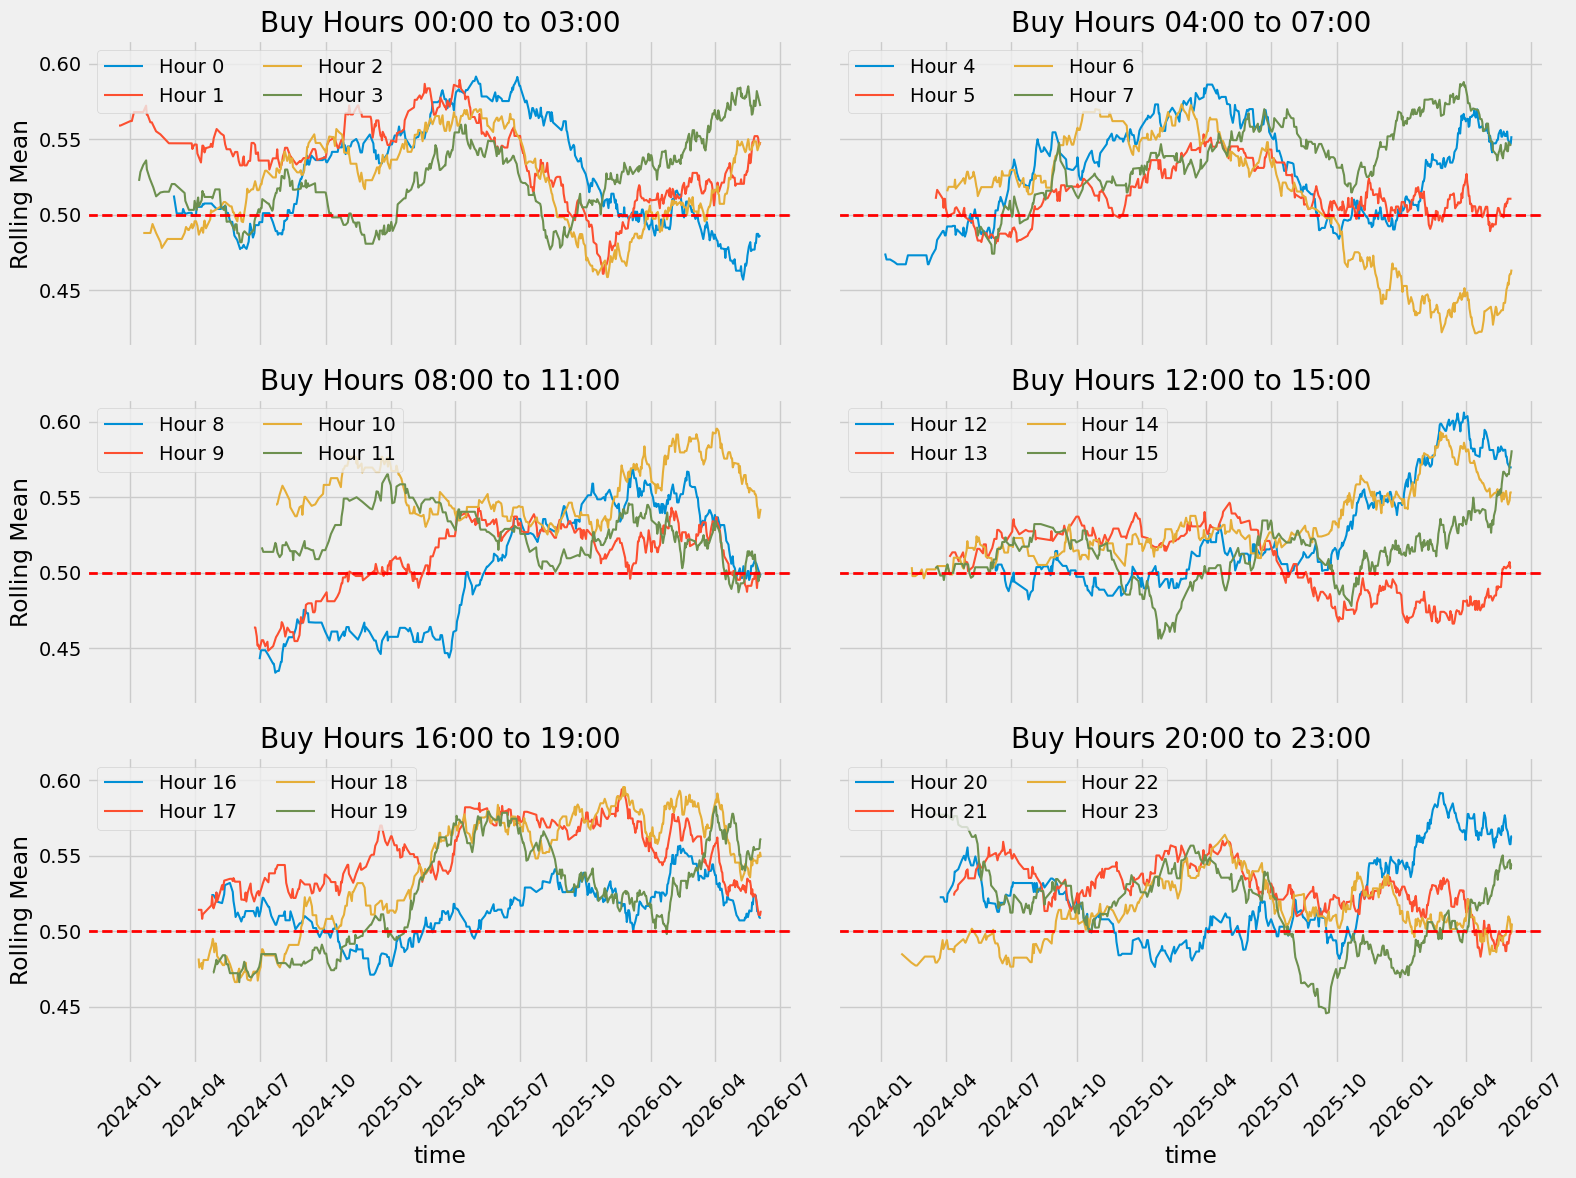

In [ ]:
# all data for the last test_time_days are test
test_date = train_df["time"].max() - pd.to_timedelta(CFG.test_time_days, unit="D")

# Pivot the data
pvt = train_buy.loc[(train_buy["time"] < test_date), ["time", "target"]]
pvt["hour"] = pvt["time"].dt.hour
pvt = pvt.pivot_table(
    index="time", columns="hour", values="target", aggfunc="mean"
)

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i in range(6):
    ax = axes[i]
    start_hour = i * 4
    end_hour = start_hour + 3

    # Plot each of the 4 hours designated for this subplot
    for hour in range(start_hour, end_hour + 1):
        if hour in pvt.columns:  # Check to ensure the hour exists in the data
            tmp = pvt[hour].dropna().rolling(window=168).mean()
            sns.lineplot(
                data=tmp, ax=ax, label=f"Hour {hour}", linewidth=1.5, legend="brief"
            )

    # Add the horizontal reference line to the current subplot
    ax.axhline(y=0.5, color="red", linestyle="--", linewidth=2)

    # Customize the current subplot
    ax.set_title(f"Buy Hours {start_hour:02d}:00 to {end_hour:02d}:00")
    ax.set_ylabel("Rolling Mean")
    ax.legend(loc="upper left", ncol=2)  # 2-column legend to save space
    ax.tick_params(axis="x", labelrotation=45)

# Adjust the layout to prevent titles/labels from overlapping
plt.tight_layout()
plt.show()

### Visualize sell hours distribution

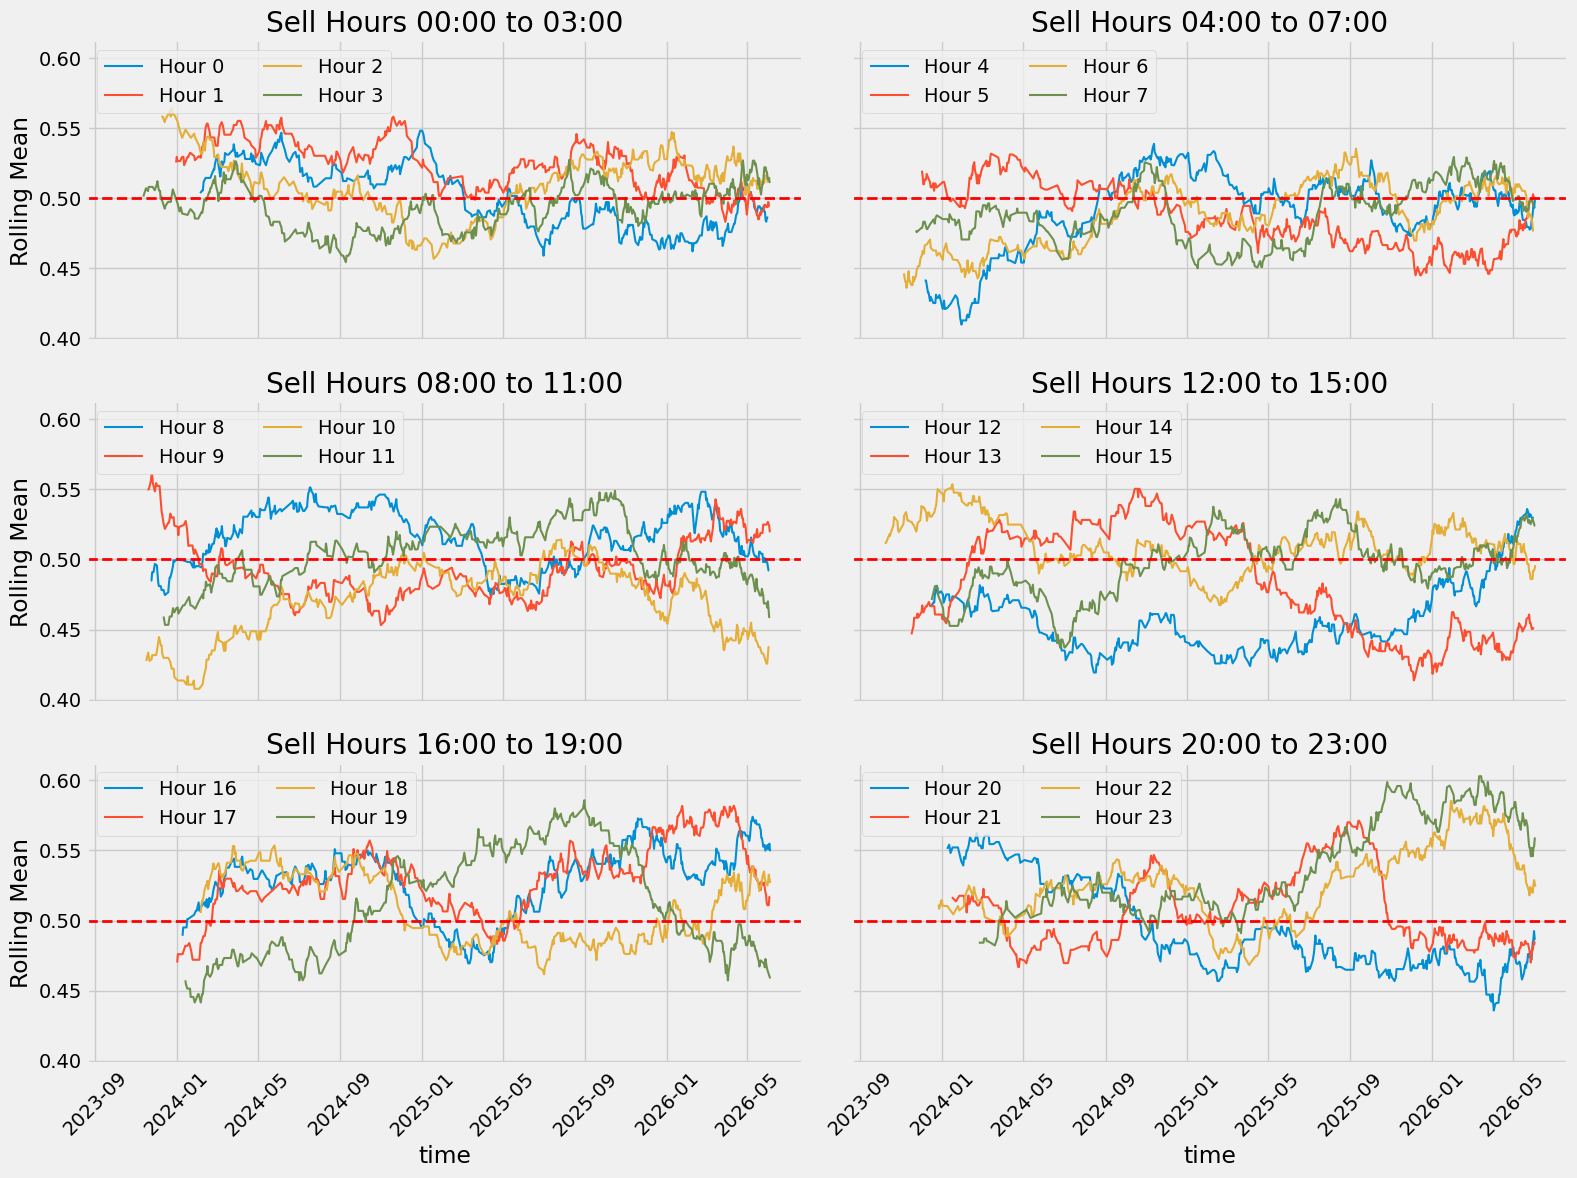

In [15]:
# Pivot the data
pvt = train_sell.loc[(train_sell["time"] < test_date), ["time", "target"]]
pvt["hour"] = pvt["time"].dt.hour
pvt = pvt.pivot_table(
    index="time", columns="hour", values="target", aggfunc="mean"
)

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 12), sharex=True, sharey=True)
axes = axes.flatten()

# Loop through the 6 subplots
for i in range(6):
    ax = axes[i]
    start_hour = i * 4
    end_hour = start_hour + 3

    # Plot each of the 4 hours designated for this subplot
    for hour in range(start_hour, end_hour + 1):
        if hour in pvt.columns:  # Check to ensure the hour exists in the data
            tmp = pvt[hour].dropna().rolling(window=168).mean()
            sns.lineplot(
                data=tmp, ax=ax, label=f"Hour {hour}", linewidth=1.5, legend="brief"
            )

    # Add the horizontal reference line to the current subplot
    ax.axhline(y=0.5, color="red", linestyle="--", linewidth=2)

    # Customize the current subplot
    ax.set_title(f"Sell Hours {start_hour:02d}:00 to {end_hour:02d}:00")
    ax.set_ylabel("Rolling Mean")
    ax.legend(loc="upper left", ncol=2)  # 2-column legend to save space
    ax.tick_params(axis="x", labelrotation=45)

# Adjust the layout to prevent titles/labels from overlapping
plt.tight_layout()
plt.show()

# Data visualization

### Plot ratio of class 1 for every week day

Monday = 0, Sunday = 6

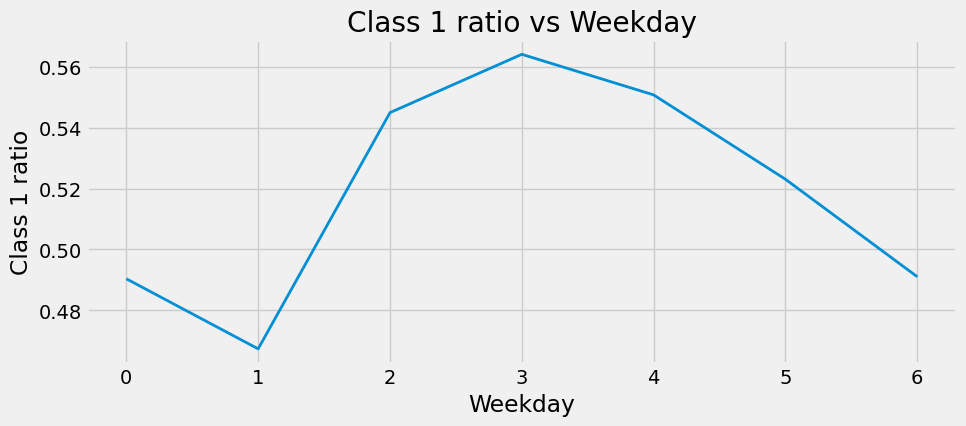

In [16]:
plt.figure(figsize=(10, 4))

group_df = train_df[(train_df["time"].dt.year >= 2020)]
group_df["weekday"] = group_df["time"].dt.weekday
ax = group_df.groupby("weekday")["target"].mean().plot()
ax.lines[0].set_linewidth(2)
ax.set_xlabel("Weekday")
ax.set_ylabel("Class 1 ratio")
ax.set_title("Class 1 ratio vs Weekday");

### Plot ratio of class 1 for every month

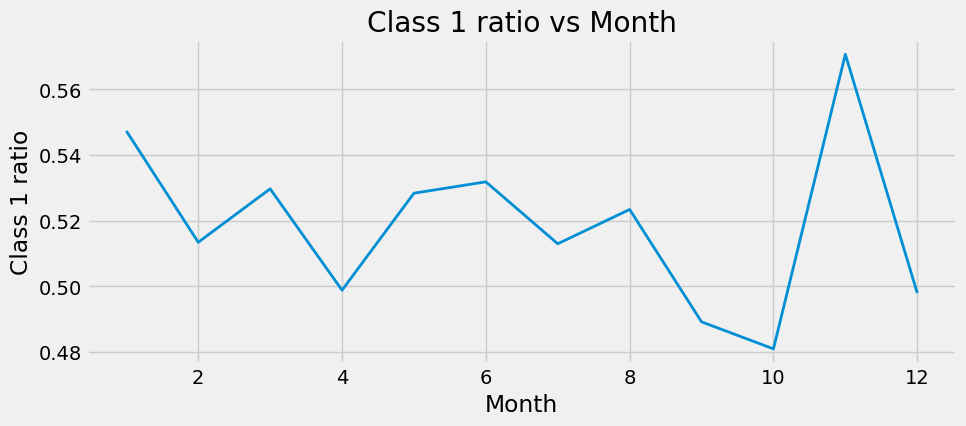

In [17]:
plt.figure(figsize=(10, 4))

group_df = train_df[(train_df["time"].dt.year >= 2020)]
group_df["month"] = group_df["time"].dt.month
ax = group_df.groupby("month")["target"].mean().plot()
ax.lines[0].set_linewidth(2)
ax.set_xlabel("Month")
ax.set_ylabel("Class 1 ratio")
ax.set_title("Class 1 ratio vs Month");

### Visualize buy trades

In [18]:
import matplotlib.pyplot as plt
import mplfinance as mpf

if CFG.create_dataset:
    plt_num = 3
    j = 1
    fig = plt.figure(figsize=(30, 6 * plt_num))

    buy_idxs = train_buy.index
    test_buy = train_buy.sample(plt_num, axis=0)


    for i, row in test_buy.iterrows():
        ticker = row["ticker"]
        time = row["time"]
        target = row["target"]
        ttype = row["ttype"]
        pattern = row["pattern"]

        df_1h, _ = get_file(ticker)
        df_1h = df_1h[(df_1h["time"] >= time) & (df_1h["time"] <= time + timedelta(hours=CFG.target_offset))]

        ohlc = df_1h[["time", "open", "high", "low", "close", "volume"]].set_index("time")
        
        price = df_1h.iloc[0]["close"]
        high_price = price * CFG.target_high_ratio
        low_price = price * CFG.target_low_ratio

        ax = fig.add_subplot(plt_num, 1, j)
        mpf.plot(ohlc, type="candle", warn_too_much_data=1001, style="yahoo", ylabel="", tz_localize=True, ax=ax)
        
        if ttype == "buy":
            ax.axhline(high_price, color="g")
            ax.axhline(low_price, color="r")
        else:
            ax.axhline(high_price, color="r")
            ax.axhline(low_price, color="g")
        ax.set_title(f"Ticker: {ticker}, price: {price}, pattern {pattern}, target: {target}", fontsize=20)
        j += 1
        
    fig.tight_layout()

### Visualize sell trades

In [19]:
if CFG.create_dataset:
    plt_num = 3
    j = 1
    fig = plt.figure(figsize=(30, 6 * plt_num))

    buy_idxs = train_sell.index
    test_sell = train_sell.sample(plt_num, axis=0)

    for i, row in test_sell.iterrows():
        ticker = row["ticker"]
        time = row["time"]
        target = row["target"]
        ttype = row["ttype"]
        pattern = row["pattern"]

        df_1h, _ = get_file(ticker)
        df_1h = df_1h[(df_1h["time"] >= time) & (df_1h["time"] <= time + timedelta(hours=CFG.target_offset))]
        
        ohlc = df_1h[["time", "open", "high", "low", "close", "volume"]].set_index("time")
        
        price = df_1h.iloc[0]["close"]
        high_price = price * CFG.target_high_ratio
        low_price = price * CFG.target_low_ratio

        ax = fig.add_subplot(plt_num, 1, j)
        mpf.plot(ohlc, type="candle", warn_too_much_data=1001, style="yahoo", ylabel="", tz_localize=True, ax=ax)
        
        if ttype == "buy":
            ax.axhline(high_price, color="g")
            ax.axhline(low_price, color="r")
        else:
            ax.axhline(high_price, color="r")
            ax.axhline(low_price, color="g")
        ax.set_title(f"Ticker: {ticker}, price: {price}, pattern {pattern}, target: {target}", fontsize=20)
        j += 1
        
    fig.tight_layout()

### Show the last signals

In [20]:
train_df.loc[train_df["pattern"] == "STOCH_RSI_Volume24", ["time", "ticker", "ttype", "pattern"]].sort_values("time").reset_index(drop=True).tail(20)

,time,ticker,ttype,pattern
114265,2026-06-03 19:00:00,RLSUSDT,sell,STOCH_RSI_Volume24
114266,2026-06-03 19:00:00,TRIAUSDT,buy,STOCH_RSI_Volume24
114267,2026-06-03 19:00:00,SSVUSDT,sell,STOCH_RSI_Volume24
114268,2026-06-03 20:00:00,FRAXUSDT,buy,STOCH_RSI_Volume24
114269,2026-06-03 20:00:00,ARUSDT,sell,STOCH_RSI_Volume24
114270,2026-06-03 20:00:00,PODUSDT,sell,STOCH_RSI_Volume24
114271,2026-06-03 20:00:00,XPLUSDT,sell,STOCH_RSI_Volume24
114272,2026-06-03 21:00:00,ENAUSDT,sell,STOCH_RSI_Volume24
114273,2026-06-03 21:00:00,SPX500USDT,buy,STOCH_RSI_Volume24
114274,2026-06-03 21:00:00,TSTBSCUSDT,buy,STOCH_RSI_Volume24


# Add time features and save train data

In [ ]:
train_df["hour"] = train_df["time"].dt.hour
train_df["weekday"] = train_df["time"].dt.weekday
train_df["month"] = train_df["time"].dt.month

train_df.to_pickle("data/train_df.pkl")

### Verify the saved artifact round-trips correctly

In [22]:
saved = pd.read_pickle("data/train_df.pkl")

combined = pd.concat([train_buy, train_sell], ignore_index=True)
dropped = int((combined["time"] == combined["time"].max()).sum())

assert len(saved) == len(combined) - dropped, \
    f"saved rows ({len(saved)}) != expected ({len(combined) - dropped})"
assert set(saved["ttype"].unique()) == {"buy", "sell"}, \
    f"saved file is missing a ttype: {set(saved['ttype'].unique())}"
print(f"Saved artifact OK: {len(saved)} rows, ttypes={set(saved['ttype'].unique())}")

Saved artifact OK: 114285 rows, ttypes={'sell', 'buy'}


# Remove the tickers that are not presented in the train dataset

In [23]:
all_tickers = glob.glob("data/tickers/*.pkl")

buy_stat_df = pd.read_pickle("data/signal_stat/buy_stat_1h.pkl")
sell_stat_df = pd.read_pickle("data/signal_stat/sell_stat_1h.pkl")
stat_tickers = set(buy_stat_df["ticker"].unique()).union(set(sell_stat_df["ticker"].unique()))

tickers_to_del = [t for t in all_tickers if t[13:-7] not in stat_tickers]
tickers_to_del

# for ticker in tickers_to_del: # !
#     os.remove(ticker)

['data/tickers/NOKSTOCKUSDT_4h.pkl',
 'data/tickers/THOLUSDT_4h.pkl',
 'data/tickers/CMC20USDT_4h.pkl',
 'data/tickers/XANDUSDT_4h.pkl',
 'data/tickers/AEROBUDUSDT_4h.pkl',
 'data/tickers/DEPUSDT_1h.pkl',
 'data/tickers/GHUBUSDT_1h.pkl',
 'data/tickers/CALUSDT_4h.pkl',
 'data/tickers/5IREUSDT_1h.pkl',
 'data/tickers/DOLANUSDT_4h.pkl',
 'data/tickers/STUFFUSDT_4h.pkl',
 'data/tickers/LETSBONKUSDT_1h.pkl',
 'data/tickers/FLYUSDT_4h.pkl',
 'data/tickers/ABDSUSDT_4h.pkl',
 'data/tickers/UNICEUSDT_1h.pkl',
 'data/tickers/FLQLONUSDT_4h.pkl',
 'data/tickers/FISHWUSDT_1h.pkl',
 'data/tickers/SATOXUSDT_1h.pkl',
 'data/tickers/SHLDUSDT_4h.pkl',
 'data/tickers/GLWSTOCKUSDT_1h.pkl',
 'data/tickers/ELYSUSDT_1h.pkl',
 'data/tickers/MOJOUSDT_1h.pkl',
 'data/tickers/MAIVUSDT_4h.pkl',
 'data/tickers/HTMUSDT_1h.pkl',
 'data/tickers/KOLZUSDT_4h.pkl',
 'data/tickers/L1USDT_4h.pkl',
 'data/tickers/ASSUSDT_4h.pkl',
 'data/tickers/DINUUSDT_1h.pkl',
 'data/tickers/1USDT_4h.pkl',
 'data/tickers/VRTONUSDT_4h.pk